# Wine Quality

## import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

## Load Dataset

In [4]:
# Load dataset
df_train = pd.read_csv('../data_training.csv')
df_test = pd.read_csv('../data_testing.csv')

# Menampilkan 5 baris pertama data training
df_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


## Cek Informasi Dataset

In [5]:
print("=== Informasi Dataset ===")
df_train.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Jumlah data per kolom ada 857 data, dimulai dari 0 sampai 856. 

In [6]:
print("\n=== Statistik Deskriptif ===")
display(df_train.describe())


=== Statistik Deskriptif ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


## Cek Missing Value

In [7]:
print("=== Jumlah Missing Value per Kolom ===")
print(df_train.isnull().sum())

=== Jumlah Missing Value per Kolom ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


tidak terdapat data yang kosong

## Cek Data Duplikat

In [8]:
jumlah_duplikat = df_train.duplicated().sum()
print(f"Terdapat {jumlah_duplikat} baris data duplikat.")

Terdapat 0 baris data duplikat.


tidak terdapat data duplikat

## Cek Keseimbangan Data

=== Distribusi Kelas 'quality' ===
quality
5    362
6    341
7    109
4     26
8     13
3      6
Name: count, dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_9540\3120310349.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='quality', palette='viridis')


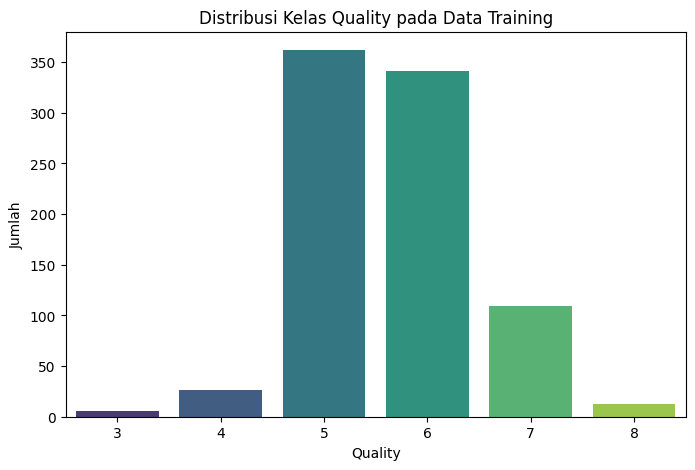

In [9]:
print("=== Distribusi Kelas 'quality' ===")
print(df_train['quality'].value_counts())

# Visualisasi Keseimbangan Data
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='quality', palette='viridis')
plt.title('Distribusi Kelas Quality pada Data Training')
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.show()

Diketahui bahwa data tidak seimbang yang dimana kelas paling tinggi yaitu quality '5' dengan jumlah data 362 dan kelas terendah quality '3' dengan jumlah data 6, sehingga perlu dilakukan sampling untuk menyeimbangkan data


## Oversampling Menggunakan SMOTE

In [10]:
# Memisahkan fitur (X) dan target (y)
# Pastikan kolom 'Id' tidak ikut dilatih jika ada di data training
if 'Id' in df_train.columns:
    X = df_train.drop(['Id', 'quality'], axis=1)
else:
    X = df_train.drop('quality', axis=1)

y = df_train['quality']

# Inisialisasi dan implementasi SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("Distribusi kelas setelah SMOTE:")
print(y_smote.value_counts())

Distribusi kelas setelah SMOTE:
quality
5    362
7    362
6    362
4    362
8    362
3    362
Name: count, dtype: int64


Oversampling dilakukan menggunakan SMOTE karena dapat menghasilkan variasi data baru yang lebih realistis dibanding random oversampling.

## Split Dataset 80:20

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_val: {X_val.shape}")

Dimensi X_train: (1737, 11)
Dimensi X_val: (435, 11)


Rasio 80:20 memastikan model memiliki porsi data yang cukup untuk belajar secara maksimal (80%), sekaligus menyisakan data yang memadai untuk menguji performanya secara objektif (20%). Sementara itu, random state=42 digunakan untuk mengunci proses pengacakan agar hasil pembagian data selalu konsisten setiap kali kode dijalankan, sehingga eksperimen tersebut akurat dan bisa diulang dengan hasil yang sama

## Persiapan Model Klasifikasi

3 Model dipilih untuk memberikan analisis komparatif yang komprehensif yakni: 
* Random Forest mewakili kekuatan prediktif dari ensemble learning
* SVM menangani batasan kelas yang kompleks secara geometris
* KNN bertindak sebagai model berbasis jarak kemiripan. 

Dengan membandingkan ketiga metodologi yang berbeda ini, pemilihan model terbaik di akhir menjadi sangat valid dan objektif secara akademis

### model knn dan svm

KNN dan SVM sangat sensitif terhadap skala data (karena KNN menggunakan perhitungan jarak dan SVM menggunakan perhitungan margin). Oleh karena itu, kita wajib melakukan Feature Scaling (Standardisasi) pada tahap ini sebelum melatih model tersebut

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Melakukan fitting dan transformasi pada data training
X_train_scaled = scaler.fit_transform(X_train)

# Hanya melakukan transformasi pada data validasi (dan data testing nanti)
# untuk mencegah data leakage
X_val_scaled = scaler.transform(X_val)

## proses training

In [17]:
# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_val_scaled)
rf_acc = accuracy_score(y_val, rf_pred)

# 2. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_val_scaled)
knn_acc = accuracy_score(y_val, knn_pred)

# 3. Support Vector Machine (SVM)
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_val_scaled)
svm_acc = accuracy_score(y_val, svm_pred)

# Menampilkan perbandingan performa
print("=== Perbandingan Akurasi Model ===")
print(f"1. Random Forest : {rf_acc * 100:.2f}%")
print(f"2. KNN           : {knn_acc * 100:.2f}%")
print(f"3. SVM           : {svm_acc * 100:.2f}%")

=== Perbandingan Akurasi Model ===
1. Random Forest : 84.83%
2. KNN           : 77.47%
3. SVM           : 77.24%


Dari ketiga model tersebut didapatkan model random forest memiliki akurasi yang paling tinggi yakni 84,83%

## seleksi model terbaik

In [18]:
# Menyimpan model dan akurasi dalam dictionary
models = {
    "Random Forest": (rf_model, rf_acc),
    "KNN": (knn_model, knn_acc),
    "SVM": (svm_model, svm_acc)
}

# Mencari model dengan akurasi tertinggi
best_model_name = max(models, key=lambda k: models[k][1])
best_model = models[best_model_name][0]

print(f"\nModel terbaik yang dipilih adalah: **{best_model_name}** dengan akurasi {models[best_model_name][1] * 100:.2f}%")


Model terbaik yang dipilih adalah: **Random Forest** dengan akurasi 84.83%


## evaluasi

=== Classification Report ===
              precision    recall  f1-score   support

           3       0.96      1.00      0.98        76
           4       0.91      0.99      0.95        70
           5       0.76      0.75      0.75        63
           6       0.67      0.59      0.63        74
           7       0.88      0.82      0.85        88
           8       0.91      1.00      0.96        64

    accuracy                           0.86       435
   macro avg       0.85      0.86      0.85       435
weighted avg       0.85      0.86      0.85       435

Akurasi Model: 85.52%



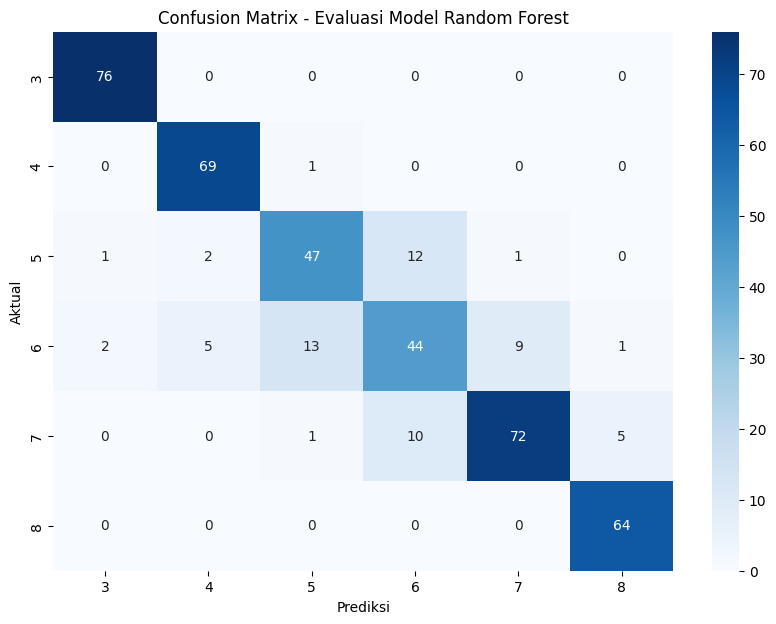

In [ ]:
# Prediksi menggunakan model terbaik pada data validasi
y_pred_best = best_model.predict(X_val_scaled)

print(f"=== Classification Report ({best_model_name}) ===")
print(classification_report(y_val, y_pred_best))

# Visualisasi Confusion Matrix untuk model terbaik
cm = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_model.classes_, 
            yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix - {best_model_name} (Model Terbaik)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## hyperparameter tunning untuk best model

Dilakukan uji lanjutan yaitu hyperparameter tunning yang ditujukan untuk mencari parameter terbaik dari best model

In [19]:
from sklearn.model_selection import GridSearchCV

print(f"=== Memulai Hyperparameter Tuning untuk {best_model_name} ===")

# Menentukan parameter grid berdasarkan model terbaik yang terpilih
if best_model_name == "Random Forest":
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42)

elif best_model_name == "KNN":
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    base_model = KNeighborsClassifier()

elif best_model_name == "SVM":
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 1],
        'kernel': ['rbf', 'linear']
    }
    base_model = SVC(random_state=42)

# Inisialisasi GridSearchCV (cv=5 berarti membagi data menjadi 5 lipatan untuk validasi silang)
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

# Melatih GridSearchCV (Mencoba semua kombinasi parameter)
# PERHATIAN: Proses ini mungkin memakan waktu beberapa menit tergantung spesifikasi komputer
grid_search.fit(X_train_scaled, y_train)

# Menampilkan hasil terbaik
print("\n[ Hasil Tuning ]")
print("Hyperparameter Terbaik:", grid_search.best_params_)
print(f"Akurasi Latih (Cross-Validation): {grid_search.best_score_ * 100:.2f}%")

# Mengambil model dengan parameter terbaik
best_tuned_model = grid_search.best_estimator_

# Evaluasi model hasil tuning pada data validasi
y_pred_tuned = best_tuned_model.predict(X_val_scaled)
tuned_acc = accuracy_score(y_val, y_pred_tuned)

print(f"\nAkurasi di Data Validasi (Setelah Tuning): {tuned_acc * 100:.2f}%")

# Menampilkan Classification Report untuk model yang sudah di-tuning
print("\n=== Classification Report (Model Tuned) ===")
print(classification_report(y_val, y_pred_tuned))

=== Memulai Hyperparameter Tuning untuk Random Forest ===
Fitting 5 folds for each of 81 candidates, totalling 405 fits

[ Hasil Tuning ]
Hyperparameter Terbaik: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Akurasi Latih (Cross-Validation): 82.38%

Akurasi di Data Validasi (Setelah Tuning): 86.44%

=== Classification Report (Model Tuned) ===
              precision    recall  f1-score   support

           3       0.97      1.00      0.99        76
           4       0.92      1.00      0.96        70
           5       0.74      0.76      0.75        63
           6       0.68      0.55      0.61        74
           7       0.87      0.88      0.87        88
           8       0.96      1.00      0.98        64

    accuracy                           0.86       435
   macro avg       0.86      0.87      0.86       435
weighted avg       0.86      0.86      0.86       435



Dalam kasus memprediksi kualitas wine (klasifikasi multiclass) maka dipakai F1-Score (Macro Average: 0.86) sebagai bukti bahwa model stabil dan adil dalam memprediksi semua tingkatan kualitas (baik anggur murah maupun premium)

## prediksi data testing dan export CSV

In [20]:
print("=== Memulai Prediksi Data Uji ===")

# Ambil kolom 'Id' dari data testing untuk file submission
test_ids = df_test['Id']

# Hapus kolom 'Id' dari fitur yang akan diprediksi agar sama dengan saat training
X_test_final = df_test.drop('Id', axis=1)

# PENTING: Lakukan scaling pada data testing menggunakan scaler yang sudah kita fit pada data training
X_test_final_scaled = scaler.transform(X_test_final)

# Lakukan prediksi menggunakan MODEL YANG SUDAH DI-TUNING
prediksi_final_tuned = best_tuned_model.predict(X_test_final_scaled)

# Membuat dataframe hasil HANYA berisi Id dan Quality (Sesuai instruksi soal)
df_submission = pd.DataFrame({
    'Id': test_ids,
    'quality': prediksi_final_tuned
})

# Menyimpan hasil ke format CSV sesuai format penamaan yang diminta (Contoh NIM: 978)
nama_file = 'hasilprediksi_016.csv'
df_submission.to_csv(nama_file, index=False)

print(f"Sukses! Prediksi menggunakan parameter terbaik telah disimpan ke '{nama_file}'.")
print("Data CSV sudah siap dikumpulkan untuk UTS Anda!")

=== Memulai Prediksi Data Uji ===
Sukses! Prediksi menggunakan parameter terbaik telah disimpan ke 'hasilprediksi_016.csv'.
Data CSV sudah siap dikumpulkan untuk UTS Anda!
